# Support-Vector Machines (SVM)

### Raw Data

In [1]:
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split

faces = fetch_olivetti_faces()
X = faces.data
y = faces.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### Preprocessing

In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Dimensionality Reduction

In [3]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_test_lda = lda.transform(X_test_scaled)

### Model Selection

In [4]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
param_grid = {
    'n_neighbors': [1, 3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

grid_search = GridSearchCV(knn, param_grid, cv=10, scoring='accuracy', verbose=1)
grid_search.fit(X_train_lda, y_train)
best_params = grid_search.best_params_

print(best_params)

Fitting 10 folds for each of 30 candidates, totalling 300 fits


/Users/robertovicario/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_split.py:725: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=10.
  warnings.warn(


{'metric': 'euclidean', 'n_neighbors': 1, 'weights': 'uniform'}


### Metrics

In [5]:
from sklearn.metrics import classification_report

knn_tuned = grid_search.best_estimator_
y_pred = knn_tuned.predict(X_test_lda)

print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     1.0000    0.6000    0.7500         5
           1     1.0000    1.0000    1.0000         4
           2     1.0000    1.0000    1.0000         2
           3     1.0000    1.0000    1.0000         4
           4     1.0000    1.0000    1.0000         3
           5     1.0000    1.0000    1.0000         3
           6     1.0000    1.0000    1.0000         3
           7     1.0000    0.8750    0.9333         8
           8     1.0000    1.0000    1.0000         2
           9     1.0000    1.0000    1.0000         3
          10     1.0000    1.0000    1.0000         3
          11     0.8333    1.0000    0.9091         5
          12     1.0000    1.0000    1.0000         2
          13     1.0000    1.0000    1.0000         3
          14     1.0000    1.0000    1.0000         3
          15     1.0000    1.0000    1.0000         3
          17     1.0000    1.0000    1.0000         3
          18     1.0000    

### Learning Curves

/Users/robertovicario/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_split.py:725: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=10.
  warnings.warn(
/Users/robertovicario/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_split.py:725: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=10.
  warnings.warn(
/Users/robertovicario/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_split.py:725: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=10.
  warnings.warn(
/Users/robertovicario/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_split.py:725: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=10.
  warnings.warn(


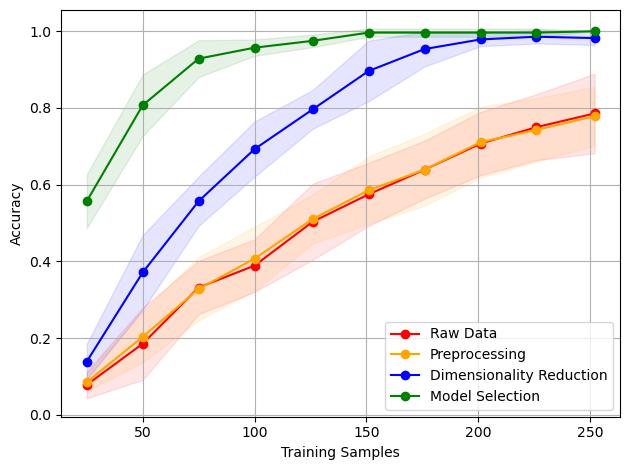

In [6]:
from matplotlib import pyplot as plt
from learning_curves import plot

knn_raw = KNeighborsClassifier()
plot(knn_raw, X_train, y_train, label="Raw Data", color="red")

X_train_scaled = scaler.fit_transform(X_train)
plot(knn_raw, X_train_scaled, y_train, label="Preprocessing", color="orange")

X_train_lda = lda.fit_transform(X_train_scaled, y_train)
plot(knn_raw, X_train_lda, y_train, label="Dimensionality Reduction", color="blue")

knn_tuned = grid_search.best_estimator_
plot(knn_tuned, X_train_lda, y_train, label="Model Selection", color="green")

plt.xlabel("Training Samples")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Confusion Matrix

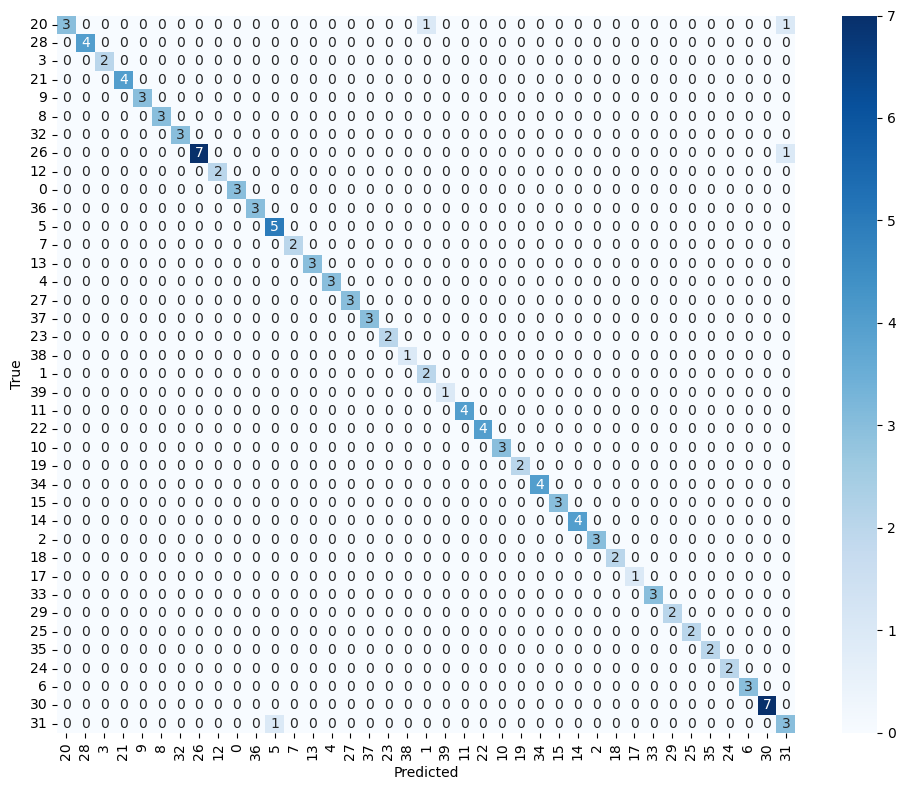

In [7]:
import seaborn as sns
from pandas import unique
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, cmap="Blues",
            xticklabels=unique(y_test),
            yticklabels=unique(y_test))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()